# Exploratory Data Analysis, Statistical Analysis and Machine Learning on the Titanic Dataset

**Course:** BCS 404 - Introduction to Data Science with Python  
**Project:** Titanic Dataset Analysis 

**Accra Technical University** — Department of Computer Science

**Lecturer:** Dr. Joseph Dadzie | **Academic Year:** 2025/2026, Second Semester 


This notebook demonstrates data acquisition, cleaning, visualisation, statistical analysis, and a simple machine learning classification model using Python.

## 1. Data Acquisition

The libraries below are used for data manipulation, numerical operations, visualisation, and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

set_config(display="text")

sns.set_theme(style="whitegrid")



The Titanic dataset is loaded from the `data` folder. The first step is to inspect the dataset dimensions, column names, first five observations, and data types.

In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
# Dataset dimensions
df.shape

(891, 12)

In [4]:
# Column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
# First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Interpretation:** The dataset contains passenger records with variables such as survival status, passenger class, sex, age, family members on board, fare, cabin, and port of embarkation.

## 2. Data Cleaning

Missing values and duplicated observations are checked. Missing values are handled using simple preprocessing decisions suitable for an introductory machine learning project.

In [7]:
# Detect missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Detect duplicate observations
df.duplicated().sum()

np.int64(0)

In [9]:
# Create a copy of the dataset for cleaning
cleaned_df = df.copy()

# Fill missing Age values with the median age
cleaned_df["Age"] = cleaned_df["Age"].fillna(cleaned_df["Age"].median())

# Fill missing Embarked values with the most common embarkation point
cleaned_df["Embarked"] = cleaned_df["Embarked"].fillna(cleaned_df["Embarked"].mode()[0])

# Drop Cabin because it has many missing values
cleaned_df = cleaned_df.drop(columns=["Cabin"])

# Remove duplicates if any exist
cleaned_df = cleaned_df.drop_duplicates()

cleaned_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Preprocessing decisions:** `Age` was filled with the median because the median is less affected by extreme values. `Embarked` was filled with the mode because it is a categorical variable with only a few missing values. `Cabin` was dropped because it contains many missing observations and may reduce the quality of the analysis if used directly.

## 3. Data Visualisation

The following charts are produced and interpreted as required by the project brief.

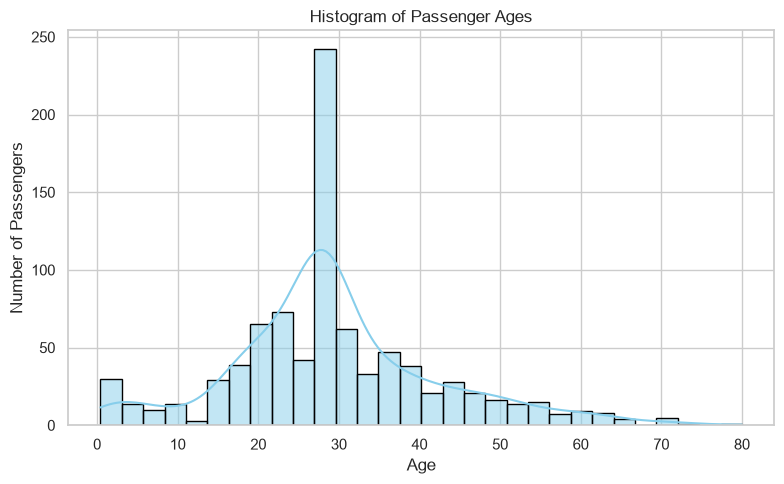

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned_df["Age"], bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("../images/age_histogram.png", dpi=180)
plt.show()

**Interpretation:** Most passengers were young adults, with a noticeable concentration around the twenties and thirties.

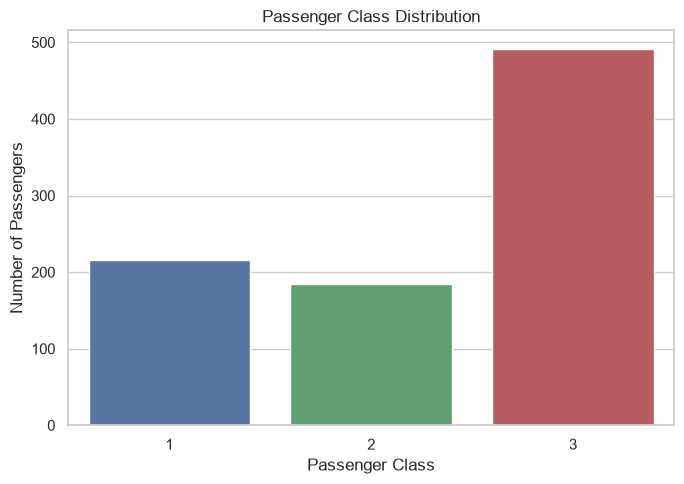

In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=cleaned_df,
    x="Pclass",
    hue="Pclass",
    order=sorted(cleaned_df["Pclass"].unique()),
    palette=["#4C72B0", "#55A868", "#C44E52"],
    legend=False
)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("../images/class_distribution.png", dpi=180)
plt.show()

**Interpretation:** Third class had the largest number of passengers, showing that many passengers travelled in the lower fare class.

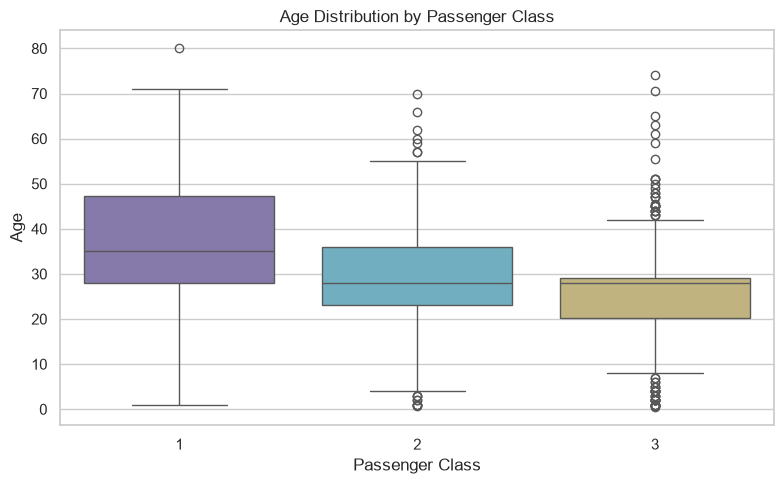

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cleaned_df,
    x="Pclass",
    y="Age",
    hue="Pclass",
    palette=["#8172B2", "#64B5CD", "#CCB974"],
    legend=False
)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("../images/age_by_class_boxplot.png", dpi=180)
plt.show()

**Interpretation:** First class passengers generally appear older than second and third class passengers. This suggests that age and passenger class may have a relationship.

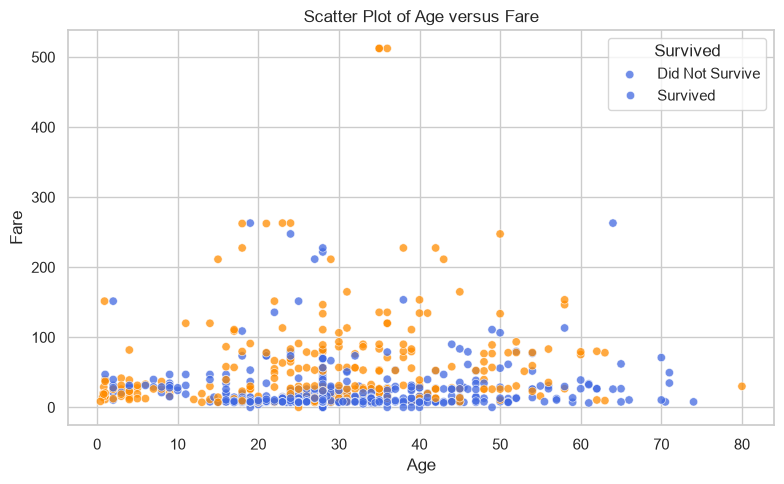

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cleaned_df,
    x="Age",
    y="Fare",
    hue="Survived",
    palette={0: "royalblue", 1: "darkorange"},
    alpha=0.75
)
plt.title("Scatter Plot of Age versus Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])
plt.tight_layout()
plt.savefig("../images/age_vs_fare_scatter.png", dpi=180)
plt.show()

**Interpretation:** Most passengers paid relatively low fares, while a few passengers paid very high fares. Some passengers with higher fares survived, suggesting that fare may have some relationship with survival.

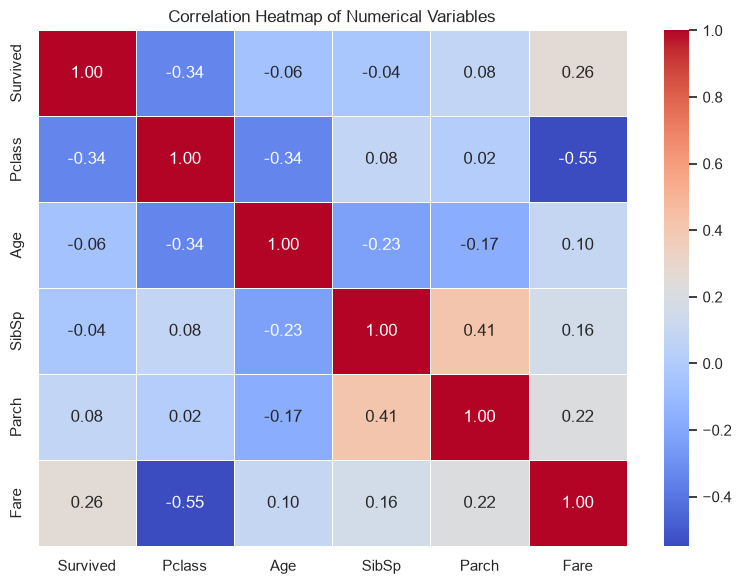

In [14]:
numeric_df = cleaned_df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=180)
plt.show()

**Interpretation:** The heatmap shows the direction and strength of relationships between numerical variables. Passenger class and fare show a strong negative relationship because higher class passengers generally paid higher fares.

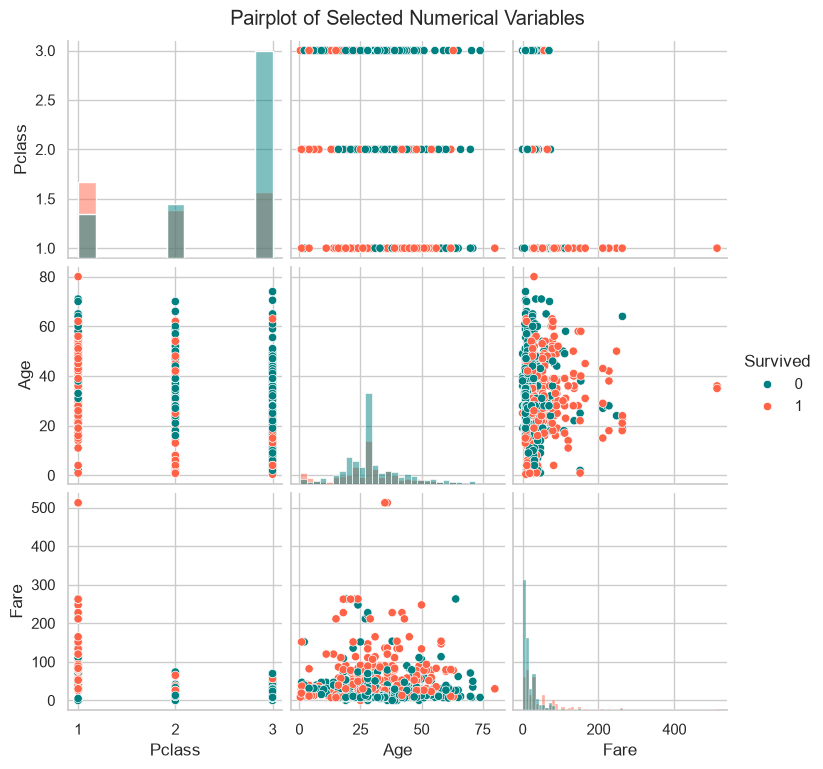

In [15]:
pair = sns.pairplot(
    cleaned_df[["Survived", "Pclass", "Age", "Fare"]],
    hue="Survived",
    palette={0: "teal", 1: "tomato"},
    diag_kind="hist"
)
pair.fig.suptitle("Pairplot of Selected Numerical Variables", y=1.02)
pair.savefig("../images/pairplot_selected_variables.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretation:** The pairplot gives a quick overview of the distributions and relationships among selected numerical variables. It helps to compare survival, passenger class, age, and fare together.

## 4. Statistical Analysis

This section includes descriptive statistics, frequency distributions, correlation analysis, and important findings.

In [16]:
# Descriptive statistics
cleaned_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
# Frequency distribution of survival
cleaned_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [18]:
# Frequency distribution of passenger class
cleaned_df["Pclass"].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [19]:
# Frequency distribution of sex
cleaned_df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [20]:
# Frequency distribution of embarkation point
cleaned_df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [21]:
# Correlation analysis
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [22]:
# Identify strongest positive and negative correlations excluding self-correlation
corr_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).stack().sort_values()
print("Strongest negative correlation:", corr_pairs.index[0], round(corr_pairs.iloc[0], 3))
print("Strongest positive correlation:", corr_pairs.index[-1], round(corr_pairs.iloc[-1], 3))

Strongest negative correlation: ('Pclass', 'Fare') -0.549
Strongest positive correlation: ('Fare', 'Fare') nan


**Three important statistical findings:**

1. The number of passengers who did not survive is higher than the number of passengers who survived.
2. Third class passengers formed the largest passenger group.
3. Fare and passenger class are strongly related, and fare also shows some positive relationship with survival.

## 5. Machine Learning

A Logistic Regression classifier is used to predict passenger survival. The target variable is `Survived`, and the predictor variables include passenger class, sex, age, number of siblings/spouses, number of parents/children, fare, and embarked location.

In [23]:
# Select predictor variables and target variable
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = cleaned_df[features]
y = cleaned_df["Survived"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

X_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [24]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((712, 8), (179, 8))

In [25]:
# Train Logistic Regression classifier
model = LogisticRegression(max_iter=1000)
_ = model.fit(X_train, y_train)

In [26]:
# Predict the testing data
y_pred = model.predict(X_test)

In [27]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8044692737430168

In [28]:
# Confusion matrix
confusion_matrix(y_test, y_pred)

array([[98, 12],
       [23, 46]])

In [29]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



**Model performance discussion:** The Logistic Regression model achieved an accuracy of approximately **80.45%** on the testing data. This means the model correctly predicted survival outcomes for a good proportion of passengers. The model is simple and interpretable, but its performance may improve with feature engineering, scaling, cross-validation, and more advanced algorithms.

## 6. Discussion and Conclusion

The analysis showed that survival on the Titanic was influenced by social and demographic factors. Passenger class, fare, sex, and age were important variables for understanding survival patterns. The Logistic Regression model provided a useful introductory classification model for predicting passenger survival. However, the study is limited by missing values, simple preprocessing, and the use of only one machine learning algorithm.